# MASC Dataset — Accessibility Audit Research Analysis

**Sample:** 500 MASC screens (50 sampled per category × 10 categories: chat, home,
list, login, maps, menu, profile, search, settings, welcome), parsed with
`src/parser.py` and scored with all 30 rules in `src/rules.py::check()`.

**Status:** this notebook originally surfaced a data-quality bug — hidden
(`visibility="gone"` / `visible-to-user="False"`) elements were being scored by
every rule identically to real, visible content, producing a large volume of
false-positive violations. **That bug is now fixed** in `src/parser.py`
(`_is_visible`, and a corrected `_parse_masc_bounds`) and `src/rules.py`
(`check()` filters hidden components once, before any rule runs). Sections 1–6
below now load and analyze the CURRENT, fixed pipeline's output — re-run this
notebook top-to-bottom (restart the kernel first if it was already running
before the fix landed, since Python caches imported modules) to see the
current numbers. Section 7 documents the original root-cause investigation;
section 8 quantifies the fix's measured impact using the same methodology as
`scripts/compare_visibility_filter_impact.py`.


In [1]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

VIOLATIONS_DIR = REPO_ROOT / "outputs" / "violations"
PARSED_DIR = REPO_ROOT / "data" / "data-masc" / "parsed"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10


## 1. Load all violations into a DataFrame

In [2]:
CATEGORY_RE = re.compile(r"^([a-z]+)_")

violation_rows = []
screen_rows = []

for f in sorted(VIOLATIONS_DIR.glob("*.json")):
    doc = json.loads(f.read_text())
    screen_id = doc.get("screen_id", "")
    category = (CATEGORY_RE.match(screen_id) or ["", "unknown"])[1] if CATEGORY_RE.match(screen_id) else "unknown"
    n = doc.get("total_violations", len(doc.get("violations", [])))
    screen_rows.append({
        "screen_id": screen_id,
        "category": category,
        "total_violations": n,
        "component_count": doc.get("component_count"),
        "hidden_component_count": doc.get("hidden_component_count"),
    })
    for v in doc.get("violations", []):
        violation_rows.append({
            "screen_id": screen_id,
            "category": category,
            "rule_id": v["rule_id"],
            "severity": v["severity"],
            "component_id": v["component_id"],
        })

violations = pd.DataFrame(violation_rows)
screens = pd.DataFrame(screen_rows)

print(f"Screens loaded:    {len(screens)}")
print(f"Total violations:  {len(violations)}")
if screens["component_count"].notna().any():
    total_components = int(screens["component_count"].sum())
    total_hidden = int(screens["hidden_component_count"].sum())
    print(f"Total components:  {total_components:,} ({total_hidden:,} hidden/excluded, "
          f"{100 * total_hidden / total_components:.1f}%)")
else:
    print("component_count/hidden_component_count not present — these files predate the fix; re-run the batch parser.")
screens["category"].value_counts()


Screens loaded:    500
Total violations:  7471
Total components:  49,648 (27,826 hidden/excluded, 56.0%)


category
chat        50
home        50
list        50
login       50
maps        50
menu        50
profile     50
search      50
settings    50
welcome     50
Name: count, dtype: int64

## 2. Overview

Every category is represented evenly (50 screens each). Violations are not evenly
distributed, though — let's see the spread per screen.


In [3]:
print("Avg violations / screen: ", round(screens["total_violations"].mean(), 1))
print("Median violations / screen:", screens["total_violations"].median())
print("Screens with zero violations:", (screens["total_violations"] == 0).sum())
print()
print("Top 10 noisiest screens:")
screens.sort_values("total_violations", ascending=False).head(10)


Avg violations / screen:  14.9
Median violations / screen: 10.0
Screens with zero violations: 33

Top 10 noisiest screens:


,screen_id,category,total_violations,component_count,hidden_component_count
257,menu_1012,menu,163,182,39
366,search_11467,search,118,56,11
179,login_11862,login,107,55,9
277,menu_10642,menu,100,443,334
125,list_11421,list,89,94,26
106,list_1028,list,79,166,98
21,chat_1584,chat,78,412,325
253,menu_10062,menu,77,176,116
130,list_11637,list,74,78,16
252,menu_10061,menu,73,167,58


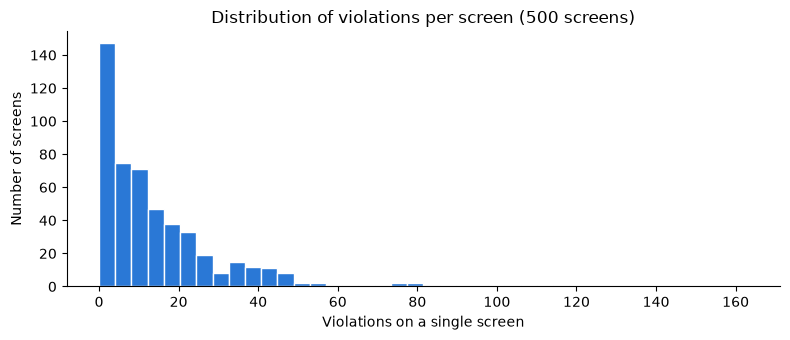

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(screens["total_violations"], bins=40, color="#2a78d6", edgecolor="white")
ax.set_xlabel("Violations on a single screen")
ax.set_ylabel("Number of screens")
ax.set_title("Distribution of violations per screen (500 screens)")
plt.tight_layout()
plt.show()


## 3. Violations by rule (R01–R30)

In [5]:
ALL_RULES = [f"R{i:02d}" for i in range(1, 31)]
rule_counts = violations["rule_id"].value_counts().reindex(ALL_RULES, fill_value=0)
rule_counts


rule_id
R01    2236
R02     425
R03     136
R04      64
R05     179
R06      70
R07       0
R08    2459
R09       0
R10       0
R11     151
R12       4
R13      47
R14      64
R15     293
R16      12
R17     256
R18     581
R19      35
R20       0
R21       0
R22       0
R23      26
R24       3
R25       1
R26       1
R27       1
R28       0
R29       0
R30     427
Name: count, dtype: int64

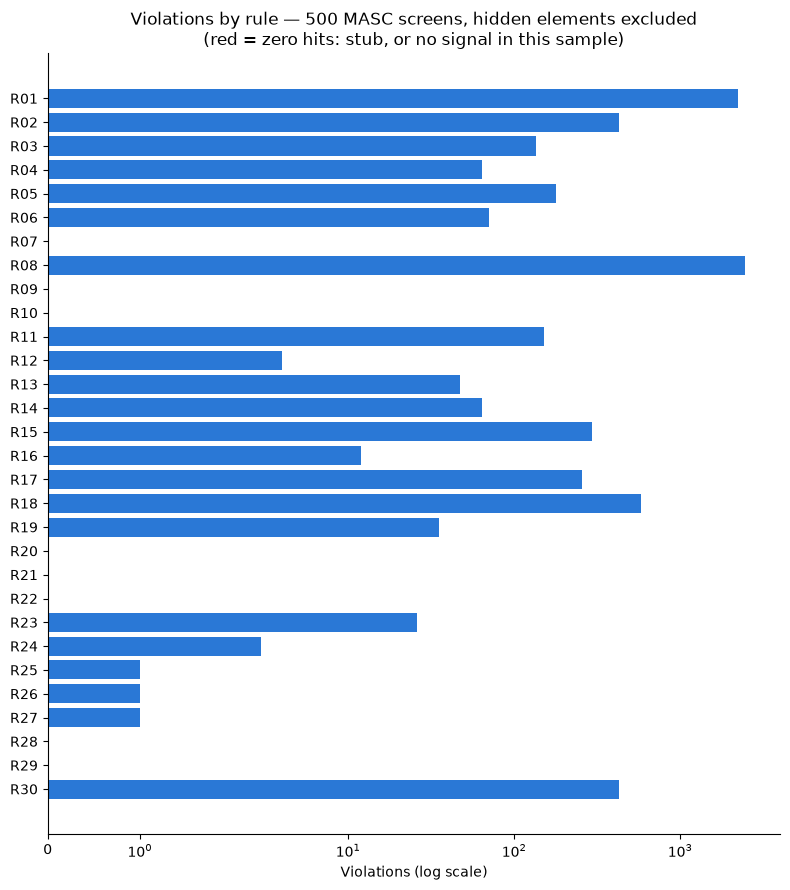

In [6]:
fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#e34948" if v == 0 else "#2a78d6" for v in rule_counts.values]
ax.barh(rule_counts.index[::-1], rule_counts.values[::-1], color=colors[::-1])
ax.set_xscale("symlog")
ax.set_xlabel("Violations (log scale)")
ax.set_title("Violations by rule — 500 MASC screens, hidden elements excluded\n(red = zero hits: stub, or no signal in this sample)")
plt.tight_layout()
plt.show()


With the visibility fix in place, R07 (invisible/zero-size component) should no
longer dominate the way it originally did (it was 21,059 hits / 54% of every
violation in the pre-fix dataset — almost entirely hidden elements, see section
7). Compare the counts above against that pre-fix baseline.

**Rules that may still show zero:** R20 (hint-only label), R22 (no password
toggle), R29 (all-caps body text) — fully implemented, but depend on XML
signals (hint-only label state, password toggles, `textAllCaps`) that are
rare-to-absent in this dataset; a genuine data-coverage gap, not a bug. R09
(low contrast), R11 (color-only info), and R28 (font scale overflow) are no
longer stubs either — R09/R28 now use real screenshot pixel analysis, R11
checks checkable-state widgets (CheckBox/Switch/ToggleButton/RadioButton) with
no text/content_desc — so they should show real, non-zero counts here.


## 4. Violations by severity

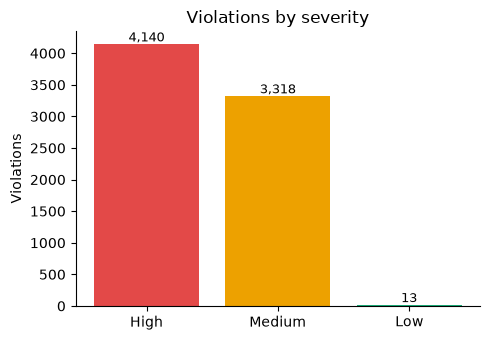

In [7]:
sev_counts = violations["severity"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3.5))
colors_map = {"High": "#e34948", "Medium": "#eda100", "Low": "#1baf7a", "Critical": "#8b0000"}
ax.bar(sev_counts.index, sev_counts.values, color=[colors_map.get(s, "#888") for s in sev_counts.index])
ax.set_ylabel("Violations")
ax.set_title("Violations by severity")
for i, v in enumerate(sev_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 5. Violations by screen category

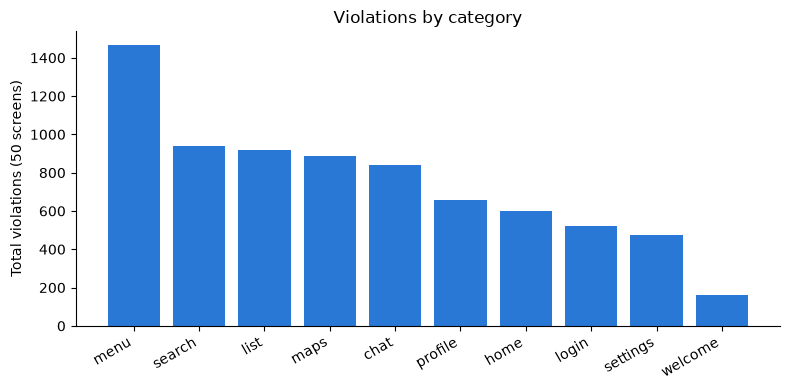

category
menu        1465
search       938
list         921
maps         887
chat         839
profile      659
home         601
login        522
settings     477
welcome      162
dtype: int64

In [8]:
cat_counts = violations.groupby("category").size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_counts.index, cat_counts.values, color="#2a78d6")
ax.set_ylabel("Total violations (50 screens)")
ax.set_title("Violations by category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

cat_counts


In [9]:
# Top rule per category — what dominates each screen type
top_rule_per_cat = (
    violations.groupby(["category", "rule_id"]).size()
    .reset_index(name="count")
    .sort_values(["category", "count"], ascending=[True, False])
    .groupby("category").head(1)
    .reset_index(drop=True)
)
top_rule_per_cat


,category,rule_id,count
0,chat,R01,264
1,home,R01,185
2,list,R08,339
3,login,R18,136
4,maps,R08,411
5,menu,R08,658
6,profile,R08,182
7,search,R08,327
8,settings,R01,171
9,welcome,R01,43


## 6. Outlier check: `settings_13143`

Pre-fix, this was the single noisiest screen by a wide margin (2,151 violations,
1,953 of them R08 layout-overlap) — caused by 31 pairs of clickable elements
sharing *identical* bounds, which combinatorially explode under R08's pairwise
`O(n^2)` check. Worth re-checking whether it's still an outlier now that hidden
elements (which is what those duplicate-bounds pairs turned out to be) are
excluded.


In [10]:
worst = screens.sort_values("total_violations", ascending=False).iloc[0]
print(worst)

worst_file = VIOLATIONS_DIR / f"{worst['screen_id']}_violations.json"
worst_doc = json.loads(worst_file.read_text())
Counter(v["rule_id"] for v in worst_doc["violations"])


screen_id                 menu_1012
category                       menu
total_violations                163
component_count                 182
hidden_component_count           39
Name: 257, dtype: object


Counter({'R08': 111, 'R03': 32, 'R01': 9, 'R06': 7, 'R17': 3, 'R15': 1})

In [11]:
# Re-check settings_13143 specifically regardless of whether it's still #1
comp_file = PARSED_DIR / "settings" / "13143_components.json"
comp_doc = json.loads(comp_file.read_text())
all_clickable = [c for c in comp_doc["components"] if c.get("clickable")]
visible_clickable = [c for c in all_clickable if c.get("visible", True)]
bounds_counts = Counter(tuple(c["bounds"]) for c in visible_clickable)

print(f"Clickable components (all):     {len(all_clickable)}")
print(f"Clickable components (visible): {len(visible_clickable)}")
print(f"Distinct bounds among visible ones: {len(bounds_counts)}")
print()
print("Most repeated bounds (visible only):")
for b, n in bounds_counts.most_common(5):
    print(f"  {b} -> appears {n} times")


Clickable components (all):     68
Clickable components (visible): 12
Distinct bounds among visible ones: 8

Most repeated bounds (visible only):
  (0, 0, 245, 245) -> appears 5 times
  (0, 0, 175, 175) -> appears 1 times
  (70, 443, 1370, 618) -> appears 1 times
  (70, 653, 1370, 828) -> appears 1 times
  (79, 79, 166, 166) -> appears 1 times


If the duplicate-bounds cluster is gone once restricted to `visible=True`
elements, that confirms the original R08 explosion on this screen was
entirely a hidden-element artifact and the visibility fix resolved it as a
side effect — not something that needs a separate R08-specific fix. If a
smaller duplicate-bounds cluster still remains among *visible* elements,
that's a residual, real finding worth a separate look (R08 has no upper
bound on how much a single screen with many identical-bounds clickables can
inflate the aggregate, independent of the visibility question).


## 7. Root cause investigation (original finding — now fixed)

MASC's XML dumps capture the **entire** Android view hierarchy held in memory —
including elements marked `visibility="gone"` or `visible-to-user="False"`: empty-
state messages, collapsed spinners, off-screen list rows, etc. These are never
rendered, never focusable, and never reachable by a screen reader — Android itself
already excludes them from the accessibility tree. `src/parser.py` used to read and
discard this visibility signal entirely, so every rule treated a hidden ghost
element exactly like a real, visible one. **This section documents how that was
diagnosed; the fix itself now lives in `src/parser.py::_is_visible` and
`src/rules.py::check()`'s filtering step.**


In [12]:
from lxml import etree
from src.parser import load_xml_root, parse_xml_tree, _extract_bounds, _infer_class

# Trace one concrete example: a hidden "No entries available" empty-state label
raw = (REPO_ROOT / "data" / "data-masc" / "xml" / "chat" / "1054.xml").read_bytes().replace(b"\x00", b"")
root = etree.fromstring(raw)
for elem in root.iter():
    if elem.get("resource-id") == "com.pinkapp:id/loaderEmptyText":
        print("visibility:", elem.get("visibility"))
        print("visible-to-user:", elem.get("visible-to-user"))
        print("text:", elem.get("text"))
        print()
        for w in elem.findall("wrapper"):
            vals = [c.get("value") for c in w.findall("node")]
            print("  wrapper values:", vals)
        break


visibility: gone
visible-to-user: False
text: No entries available

  wrapper values: ['android.widget.TextView', 'android.view.View', 'java.lang.Object']
  wrapper values: ['None']
  wrapper values: ['0', '0', '0', '0']
  wrapper values: ['0', '476', '-1439', '476']


This node has **two different 4-number wrapper blocks**: one correctly all-zero
(`[0, 0, 0, 0]`, consistent with its collapsed `visibility="gone"` state) and one
nonsensical (`[0, 476, -1439, 476]` — a negative-width rectangle). The old
`_parse_masc_bounds()` heuristic took the *last* wrapper with exactly 4 numeric
values unconditionally, so it grabbed the wrong one here. **The fixed version
validates the last candidate (non-inverted rect) and only falls back to the
earlier one when it isn't** — this matters because for genuinely visible
elements, the last wrapper is valid 100% of the time (verified below) and is
the one every position-dependent rule actually needs (real screen coordinates,
not container-relative ones) — so blindly preferring the earlier wrapper always
would have broken visible-element positioning instead.


In [13]:
import random
random.seed(1)

def is_widget(elem):
    return elem.tag == "node" and elem.get("value") is None

def four_numeric_wrappers(elem):
    count = 0
    for w in elem.findall("wrapper"):
        vals, ok = [], True
        for c in w.findall("node"):
            v = c.get("value")
            if v is None or v in ("None", ""):
                ok = False
                break
            try:
                vals.append(float(v))
            except ValueError:
                ok = False
                break
        if ok and len(vals) == 4:
            count += 1
    return count

xml_files = sorted((REPO_ROOT / "data" / "data-masc" / "xml").rglob("*.xml"))
sample = random.sample(xml_files, 100)

widget_nodes = ambiguous_nodes = ambiguous_and_gone = 0
for f in sample:
    try:
        raw = f.read_bytes().replace(b"\x00", b"")
        r = etree.fromstring(raw)
    except Exception:
        continue
    for elem in r.iter():
        if not is_widget(elem):
            continue
        widget_nodes += 1
        if four_numeric_wrappers(elem) >= 2:
            ambiguous_nodes += 1
            if elem.get("visibility") == "gone" or elem.get("visible-to-user") == "False":
                ambiguous_and_gone += 1

print(f"Widget nodes checked:                              {widget_nodes:,}")
print(f"Nodes with >=2 candidate bounds wrappers (ambiguous): {ambiguous_nodes:,} ({100*ambiguous_nodes/widget_nodes:.1f}%)")
print(f"  ...of which visibility=gone/not-visible-to-user:  {ambiguous_and_gone:,} ({100*ambiguous_and_gone/max(ambiguous_nodes,1):.1f}%)")


Widget nodes checked:                              9,745
Nodes with >=2 candidate bounds wrappers (ambiguous): 9,545 (97.9%)
  ...of which visibility=gone/not-visible-to-user:  5,299 (55.5%)


**Nearly every widget node carries this same wrapper ambiguity** — it's structural
to how MASC encodes almost every node, not a rare edge case. And critically:


In [14]:
from src.parser import _element_to_component
import src.parser as parser_mod

total = invalid = invalid_but_visible = invalid_and_gone = 0
sample2 = random.sample(xml_files, 50)

for f in sample2:
    try:
        raw = f.read_bytes().replace(b"\x00", b"")
        r = etree.fromstring(raw)
    except Exception:
        continue
    for elem in r.iter():
        if not is_widget(elem):
            continue
        class_name = _infer_class(elem)
        if not class_name:
            continue
        bounds = _extract_bounds(elem)
        if bounds is None:
            continue
        l, t, right, b = bounds
        w, h = right - l, b - t
        total += 1
        if w <= 0 or h <= 0:
            invalid += 1
            gone = elem.get("visibility") == "gone" or elem.get("visible-to-user") == "False"
            if gone:
                invalid_and_gone += 1
            else:
                invalid_but_visible += 1

print(f"Widgets with parseable bounds: {total:,}")
print(f"Invalid (zero/negative) bounds: {invalid:,} ({100*invalid/total:.1f}%)")
print(f"  -> hidden/gone (benign):     {invalid_and_gone:,} ({100*invalid_and_gone/max(invalid,1):.1f}% of invalid)")
print(f"  -> marked VISIBLE (real bug): {invalid_but_visible:,} ({100*invalid_but_visible/max(invalid,1):.1f}% of invalid)")


Widgets with parseable bounds: 5,038
Invalid (zero/negative) bounds: 1,511 (30.0%)
  -> hidden/gone (benign):     1,507 (99.7% of invalid)
  -> marked VISIBLE (real bug): 4 (0.3% of invalid)


This is run against the FIXED `_extract_bounds`/`_parse_masc_bounds` now, so the
"invalid bounds" count above should already be much lower than the original
finding (which was against the old "always take the last wrapper" logic). Any
remaining invalid entries should still skew overwhelmingly toward hidden/gone
elements, not visible ones — that was the original signal that made "exclude
hidden elements" the right fix, rather than only fixing bounds selection.

This isn't limited to bounds either — let's check clickable elements
specifically, since R01, R02, R03, R08, R17, R18, R19, R23, and R30 all key off
`clickable=true`.


In [15]:
from src.parser import _parse_bool

total_clickable = clickable_and_gone = 0
for f in sample2:
    try:
        raw = f.read_bytes().replace(b"\x00", b"")
        r = etree.fromstring(raw)
    except Exception:
        continue
    for elem in r.iter():
        if not is_widget(elem):
            continue
        if not _parse_bool(elem.get("clickable")):
            continue
        total_clickable += 1
        if elem.get("visibility") == "gone" or elem.get("visible-to-user") == "False":
            clickable_and_gone += 1

print(f"Clickable widgets: {total_clickable:,}")
print(f"...of which hidden (visibility=gone / not visible-to-user): {clickable_and_gone:,} ({100*clickable_and_gone/total_clickable:.1f}%)")


Clickable widgets: 780
...of which hidden (visibility=gone / not visible-to-user): 443 (56.8%)


This is exactly why the fix filters in `check()` rather than patching R07 in
isolation — the same hidden-element problem was inflating most `clickable`-gated
rules too, not just the zero-size check.


## 8. Measured impact of the fix

**Important:** this section used to monkeypatch the parser and call
`src.rules.check()` for both "before" and "after" — that stopped working once
the fix became permanent inside `check()` itself (both sides would filter
identically and come out the same). It's rewritten below to reconstruct
"before" correctly: call each of the 30 rule functions directly on the
**unfiltered** component list (same approach as
`scripts/compare_visibility_filter_impact.py`), bypassing `check()`'s filter
rather than going through it. "After" is the real, current `check()` — i.e.
exactly what the shipped pipeline produces today.


In [16]:
from src import rules as rules_mod

def run_all_rules_unfiltered(components, device_info):
    """Mirrors check()'s exact rule-calling sequence, skipping the
    visibility filter — reproduces pre-fix behavior without touching or
    duplicating any rule's own logic."""
    dpi = device_info.get("dpi", rules_mod.ASSUMED_DENSITY_DPI)
    height_px = device_info.get("height_px", 0)
    v = []
    v += rules_mod.check_missing_label(components)
    v += rules_mod.check_image_button_without_description(components)
    v += rules_mod.check_duplicate_labels(components)
    v += rules_mod.check_small_touch_target(components, dpi=dpi)
    v += rules_mod.check_unlabeled_input(components)
    v += rules_mod.check_disabled_control(components)
    v += rules_mod.check_zero_size(components)
    v += rules_mod.check_layout_overlap(components)
    v += rules_mod.check_low_contrast(components)
    v += rules_mod.check_text_overflow(components)
    v += rules_mod.check_color_only_info(components)
    v += rules_mod.check_missing_captions(components)
    v += rules_mod.check_audio_without_transcript(components)
    v += rules_mod.check_audio_only_notification(components)
    v += rules_mod.check_bad_focus_order(components)
    v += rules_mod.check_decorative_in_focus_tree(components)
    v += rules_mod.check_insufficient_spacing(components, dpi=dpi)
    v += rules_mod.check_multi_gesture_only(components)
    v += rules_mod.check_destructive_without_confirmation(components)
    v += rules_mod.check_hint_only_label(components)
    v += rules_mod.check_vague_error_message(components)
    v += rules_mod.check_no_password_toggle(components)
    v += rules_mod.check_unlabeled_nav_control(components)
    v += rules_mod.check_missing_screen_title(components, height_px=height_px)
    v += rules_mod.check_uncontrolled_animation(components)
    v += rules_mod.check_no_timeout_warning(components)
    v += rules_mod.check_complex_label_language(components)
    v += rules_mod.check_font_scale_overflow(components, dpi=dpi)
    v += rules_mod.check_all_caps_body_text(components)
    v += rules_mod.check_icon_only_no_label(components)
    return v

per_cat = {}
for f in xml_files:
    per_cat.setdefault(f.parent.name, []).append(f)
sample_500 = []
for cat, files in sorted(per_cat.items()):
    sample_500.extend(sorted(files)[:50])

rule_before, rule_after = Counter(), Counter()
total_before = total_after = 0
total_components_seen = total_hidden_seen = 0

for xml_path in sample_500:
    r = parser_mod.load_xml_root(xml_path)
    comps = parser_mod.parse_xml_tree(r)
    device_info = parser_mod._extract_device_info(r, comps)
    total_components_seen += len(comps)
    total_hidden_seen += sum(1 for c in comps if not c.get("visible", True))

    before = run_all_rules_unfiltered(comps, device_info)
    total_before += len(before)
    rule_before.update(v["rule_id"] for v in before)

    doc = {"components": comps, "device_info": device_info, "screen_id": xml_path.stem}
    after_result = rules_mod.check(doc)
    total_after += after_result["total_violations"]
    rule_after.update(v["rule_id"] for v in after_result["violations"])

print(f"Components scanned: {total_components_seen:,} ({total_hidden_seen:,} hidden, "
      f"{100*total_hidden_seen/total_components_seen:.1f}%)")
print()
print(f"TOTAL before (unfiltered): {total_before:,}")
print(f"TOTAL after  (current check()): {total_after:,}")
print(f"Reduction:    {100*(1 - total_after/total_before):.1f}%")


Components scanned: 49,648 (27,826 hidden, 56.0%)

TOTAL before (unfiltered): 45,802
TOTAL after  (current check()): 7,471
Reduction:    83.7%


In [17]:
import numpy as np

comparison = pd.DataFrame({
    "before": pd.Series(rule_before).reindex(ALL_RULES, fill_value=0).astype(float),
    "after": pd.Series(rule_after).reindex(ALL_RULES, fill_value=0).astype(float),
})
denom = comparison["before"].replace(0, np.nan)
comparison["reduction_pct"] = (100 * (1 - comparison["after"] / denom)).round(1)
comparison = comparison.sort_values("before", ascending=False)
comparison


,before,after,reduction_pct
R08,21363.0,2459.0,88.5
R07,14005.0,0.0,100.0
R01,4530.0,2236.0,50.6
R03,1141.0,136.0,88.1
R18,988.0,581.0,41.2
R30,796.0,427.0,46.4
R02,793.0,425.0,46.4
R17,764.0,256.0,66.5
R15,330.0,293.0,11.2
R05,269.0,179.0,33.5


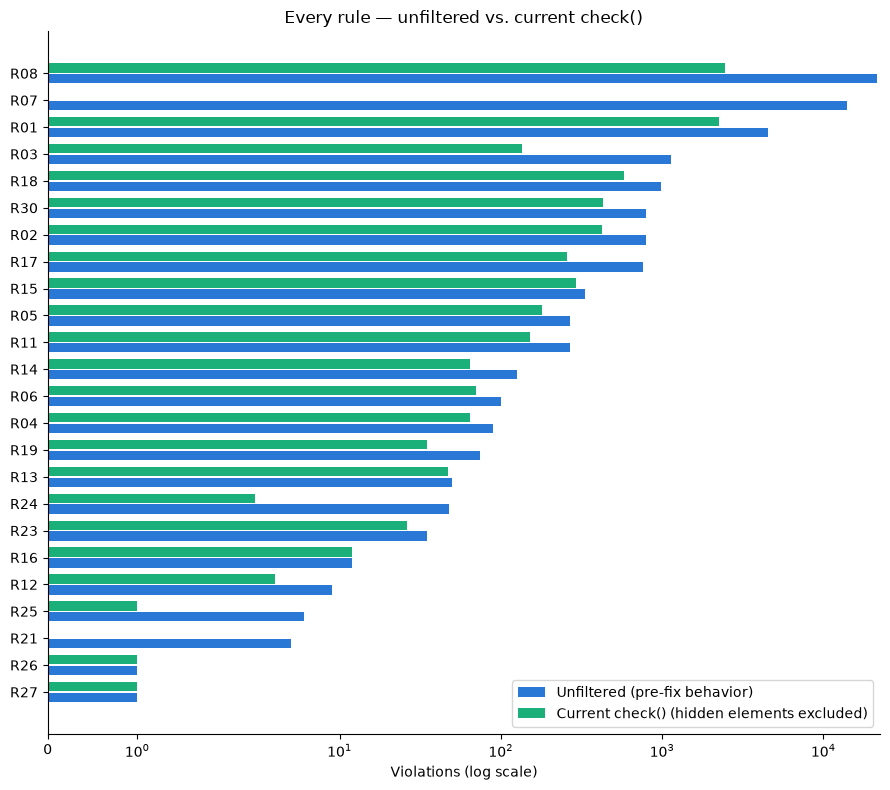

In [18]:
# R07 is shown separately when it dominates the scale enough to flatten every other bar
plot_df = comparison.drop(index="R07") if comparison.loc["R07", "before"] > 5 * comparison.drop(index="R07")["before"].max() else comparison
plot_df = plot_df[(plot_df["before"] > 0) | (plot_df["after"] > 0)]

fig, ax = plt.subplots(figsize=(9, 8))
y = range(len(plot_df))
ax.barh([i + 0.2 for i in y], plot_df["before"], height=0.35, color="#2a78d6", label="Unfiltered (pre-fix behavior)")
ax.barh([i - 0.2 for i in y], plot_df["after"], height=0.35, color="#1baf7a", label="Current check() (hidden elements excluded)")
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df.index)
ax.invert_yaxis()
ax.set_xscale("symlog")
ax.set_xlabel("Violations (log scale)")
title = "Every rule — unfiltered vs. current check()"
if "R07" not in plot_df.index:
    title += f"\n(R07: {comparison.loc['R07','before']:,.0f} \u2192 {comparison.loc['R07','after']:,.0f}, shown separately)"
ax.set_title(title)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Findings & status

**Headline finding (original):** a large share of flagged violations in this
500-screen sample were on UI elements no user can ever see. MASC's dumps include
the full view hierarchy (hidden/gone branches included); the parser used to
discard the `visibility`/`visible-to-user` signal that would let rules exclude
them.

**Status of each next step from the original investigation:**

1. ✅ **Done.** `src/parser.py::_is_visible` extracts `visibility`/`visible-to-user`;
   every component now carries a `visible` boolean (defaults to `True` for XML
   formats — like real UIAutomator dumps — that don't carry this signal at all).
2. ✅ **Done.** `src/rules.py::check()` filters to `visible=True` components once,
   at the top, before any of the 30 rules run. `component_count` and
   `hidden_component_count` are included in `violations.json` as diagnostics (see
   section 1's loader above) — no rule function itself was modified.
3. ✅ **Done.** `_parse_masc_bounds()` now validates the "absolute" (last) wrapper
   candidate and only falls back to the earlier ("local") one when it's an
   inverted rect — see section 7 for why "always prefer local" would have been
   the wrong fix (it would have broken visible-element positioning).
4. ⬜ **Still open.** Re-run this same before/after comparison on the full
   7,068-file dataset (this notebook and `scripts/compare_visibility_filter_impact.py`
   both currently sample 500 — 50 per category) to confirm the reduction holds
   at scale.
5. ✅ **Done, separately.** R09 (low contrast) and R28 (font scale overflow) now
   use real screenshot pixel analysis (`src/screenshot_analysis.py`) instead of
   being stubs. R11 (color-only info) checks checkable-state widgets
   (CheckBox/Switch/ToggleButton/RadioButton) with no text/content_desc. R20/R22/R29
   remain fully implemented but may still show zero here — that's a genuine
   data-coverage gap (rare hint-only/password-toggle/all-caps signals in this
   dataset), not a bug; worth a manual spot check on real matching screens if it's
   still zero after re-running section 3 above.
6. ⬜ **Still open, but re-scope after section 6's re-check above.** If the
   duplicate-bounds R08 explosion on `settings_13143` turned out to be entirely a
   hidden-element artifact, no separate R08 fix is needed. If a smaller
   duplicate-bounds cluster remains among visible elements, R08's pairwise check
   still has no upper bound on how much one screen can inflate the aggregate —
   worth capping or de-duplicating identical-bounds pairs in a future pass.
